playground is to try to set up nist handling for other 2d formats

need to have code run nist detector first, if nist data detected, run trad_spec(). 
can't have other formats work with nist data because only strong lines are included. would have to do a "reverse calibration" to find in between values in order to plot other graphs. 
    exception might be gaussian plots. b/c gaussian is similar to trad, might be able to have it deal with nist data

1. run nist detector
2. if nist data detected, prompt user: "Nist Data Detected. Choose: Gaussian or Traditional Graph Type.", render accordingly
3. if NO nist data detected, run like normal (like current setup)

In [29]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import utils
import nist_codes
import matplotlib.patheffects as pe
import new_utils
import math

In [30]:
y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1
min_alpha = 0.1
min_alpha_scatter = 0.2
base_marker_size = 5
max_marker_size_factor = 95
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing - lower window = sharper/taller peaks
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
x_min = 400
x_max = 750
reverse_x = True
show_grid = True
#plot_type = None

In [31]:
def round_to_multiple(num, mult):
    rounded = math.ceil(num / mult) * mult 
    return rounded

def scale_by_int():
    global SCALE_BY_INT
    scale = input("Scale brightness by intensity? Yes or No").lower()
    if scale == 'yes' or scale == 'y':
        SCALE_BY_INT = 'yes'
    elif scale == 'no' or scale == 'n':
        SCALE_BY_INT = 'no'
    print('\nScale brightness:', SCALE_BY_INT.capitalize())

In [32]:
H_SHEET = "h test.xlsx"
HE_SHEET = "he test.xlsx"
NIST_SHEET = "oxygen nist 2.xlsx"

H_DF = pd.read_excel(H_SHEET)
HE_DF = pd.read_excel(HE_SHEET)
NIST_DF = pd.read_excel(NIST_SHEET)

global df  
df = NIST_DF

detection_col = '_raw_int'
int_col = '_adj_int'

In [33]:
def get_graph_type():
    global graph_type, plot_type
    plot_type = None
    GRAPH_TYPE = input("Choose Graph Type: Line, Bar, Scatter, Gaussian, Traditional").lower()
    if GRAPH_TYPE == 'bar' or GRAPH_TYPE == 'b':
        graph_type = 'bar'
    elif GRAPH_TYPE == 'scatter' or GRAPH_TYPE == 's':
        graph_type = 'scatter'
    elif GRAPH_TYPE == 'gaussian' or GRAPH_TYPE == 'g':
        graph_type = 'gaussian'
    elif GRAPH_TYPE == 'line' or GRAPH_TYPE == 'l':
        FILL_TYPE = input("Filled Graph? Choose: Yes or No").lower()
        if FILL_TYPE == 'yes' or FILL_TYPE == 'y':
            PLOT_TYPE = input("Smoothed Fill? Choose: Yes or No").lower()
            if PLOT_TYPE == 'yes' or PLOT_TYPE == 'y':
                graph_type = 'smoothed line'
                plot_type = 'Smoothed'
            elif PLOT_TYPE == 'n' or PLOT_TYPE == 'no':
                graph_type = 'filled line'
                plot_type = 'filled'
        else:
            graph_type = 'line'           
    elif GRAPH_TYPE == 'traditional' or GRAPH_TYPE == 'trad' or GRAPH_TYPE == 't':
        graph_type = 'traditional'
    
    return GRAPH_TYPE

In [34]:
def run_nist_check(data_df, force_nist=None):

    df_data = data_df.copy()
    new_utils.res_col_names(data_df=df_data, nm_col=None, int_col=None,)
    df_data[new_utils.wl_col] = pd.to_numeric(df_data[new_utils.wl_col], errors='coerce')
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_data[new_utils.INT_col], force_nist=force_nist)

    return df_data, has_any_nist

In [48]:
def prep_with_nist(data_df, force_nist=None, x_min=x_min, x_max=x_max, apply_descriptor_adjustments=False,):
    global int_range

    new_utils.res_col_names(data_df=data_df, nm_col=None, int_col=None,)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[new_utils.wl_col] = pd.to_numeric(df_plot_data[new_utils.wl_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[new_utils.INT_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('NIST Destriptors Detected. Preparing NIST Rendering.')
    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')

    # parse NIST-style cells
    parsed_intensity = df_plot_data[new_utils.INT_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[new_utils.wl_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[new_utils.wl_col] >= x_min) & (df_plot_data[new_utils.wl_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=new_utils.wl_col).reset_index(drop=True)

    # returns empty flag for empty datasets
    if df_plot_data.empty:
        return None, True 

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    return df_plot_data, False, has_any_nist


In [36]:
# set conditional that if new_utils.plot_type == 'Smoothed', then this prep function is used. otherwise prep_trad_spec() should be used (will be changing the name of the function)

def prep_other(data_df, x_min = x_min, x_max = x_max):

    global int_range
    global y_max

    new_utils.res_col_names(data_df=data_df, nm_col=None, int_col=None,)
    df_filtered = data_df.copy()
    df_filtered = df_filtered[(df_filtered[new_utils.wl_col] >= x_min) & (df_filtered[new_utils.wl_col] <= x_max)].copy()
    df_filtered = df_filtered.sort_values(by=new_utils.wl_col).reset_index(drop=True)

    if plot_type == 'Smoothed':
        df_filtered['Smoothed_int'] = df_filtered[new_utils.INT_col].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered[new_utils.INT_col])
        min_int = df_filtered['Smoothed_int'].min()
        max_int = df_filtered['Smoothed_int'].max()
    else:
        min_int = df_filtered[new_utils.INT_col].min()
        max_int = df_filtered[new_utils.INT_col].max()

    int_range = max_int - min_int
    int_vals = df_filtered[new_utils.INT_col]
    y_max = int_vals.max()

    if int_range == 0:
        df_filtered['Norm_Int'] = 1.0
    else:
        if plot_type == 'Smoothed':
            df_filtered['Norm_Int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
        else:
            df_filtered['Norm_Int'] = (df_filtered[new_utils.INT_col] - min_int) / int_range

    if df_filtered.empty:
        return None, True 

    return df_filtered, False

In [ ]:
# code breaks when this is used. prep_with_nist() doesn't pass properly so it causes KeyErrors. 

def early_exit(data_df):
    global has_any_nist
    df_plot_data, should_exit_early, has_any_nist = prep_with_nist(data_df = data_df)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=utils.DPI)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    return df_plot_data, should_exit_early

In [83]:
# prep_other() doesn't pass properly. causes KeyErrors

def early_exit_other(data_df):
    data_df, should_exit_early = prep_other(data_df = data_df)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=new_utils.fig_size, dpi=utils.DPI)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    return data_df, should_exit_early

In [37]:
# updated to work with trad_spec(). eventually want it to work with set_generic_type()

def plot(
    df_plot_data,
    nm_col,
    has_any_nist,
    prominence_percentage=0,     
    fig_size=utils.FIG_SIZE,
    min_brightness=0,
    peak_wavelengths=None,
    show_peak_labels=True,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=utils.DPI,
    peak_label_y_position=0,
    label_min_norm_int=utils.LABEL_NORM_INT,
    apply_descriptor_adjustments = False,
    subplots_adjust_top = 0.90,
    max_needle_y = utils.MAX_Y_SCALE,
    fig_height_overflow_scale = utils.fig_height_overflow_scale,
    fig_height_base = utils.FIG_HEIGHT_BASE,
):

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    new_utils.trad_spec_labels(fig=fig, ax=ax, x_min=x_min, x_max=x_max)

    if has_any_nist:
        new_utils.generic_type = None
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN

    else:
        new_utils.get_generic_type()
        if new_utils.generic_type == 'raw':
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        elif new_utils.generic_type == 'normalised':
            glow_alpha = utils.NORM_GLOW_ALPHA
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN

    # --- Peak Detection ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[new_utils.wl_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if new_utils.generic_type=='raw':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if new_utils.generic_type == 'normalised':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[new_utils.INT_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][new_utils.wl_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]

    init_peak_label_y_posn = peak_label_y_position
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=init_peak_label_y_posn,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [init_peak_label_y_posn] * len(peaks)

    if label_ys:
        max_label_y = max(label_ys)
        overflow = max(0, max_label_y - init_peak_label_y_posn)
        print("\noverflow:", overflow)
        print("o.g. peak label y pos'n:", init_peak_label_y_posn)
        if overflow > 0:
            new_height = fig_height_base + overflow * fig_height_overflow_scale
            new_fig_height = new_height
            fig.set_figheight(new_height)
           
            current_needle_height_in = max_needle_y * new_height
            new_needle_height = (max_needle_y * fig_height_base) / new_height 
            max_needle_y_scale = new_needle_height
            new_peak_y_posn = (init_peak_label_y_posn * fig_height_base) / new_height
            peak_label_y_position = new_peak_y_posn
            
            print("needle height goal:", new_needle_height, "\n \t inches:", new_needle_height*new_height)
            print("current needle height (in):", current_needle_height_in)
            print("height:", new_height, "max label y:", max_label_y)
            print("\npeak label y pos'n goal:", new_peak_y_posn, "\nnew fig height:", new_fig_height)      
        else:
            print("Labels fit — no expansion needed")
            max_needle_y_scale = max_needle_y
            print("peak label y pos'n:", peak_label_y_position)
    else:
        max_needle_y_scale = max_needle_y
        print("No labels on this spectrum")

    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")

    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,   # now uses updated value
            min_sep_nm=1.5,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.85,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)

    print("\n new peak label pos'n:", peak_label_y_position)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = new_utils.final_scale(min_brightness, _ni)
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = new_utils.left_x(_nm, _bg_widths)
        _x_right = new_utils.right_x(_nm, _bg_widths)
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or new_utils.generic_type == 'raw':
            _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = utils.DEFAULT_MIN_BRIGHT
        elif new_utils.generic_type == 'normalised':
            _peak_emphasis = utils.NORM_PEAK_EMPHASIS
            min_brightness = utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity
        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)

        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        
        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render))

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = new_utils.left_x(peak_nm, glow_current_widths_nm)
        glow_x_right = new_utils.right_x(peak_nm, glow_current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = new_utils.dynamic_prominence(scaled_max_width_nm, width_profile_factor)
        x_left = new_utils.left_x(peak_nm, current_widths_nm)
        x_right = new_utils.right_x(peak_nm, current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or new_utils.generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if new_utils.generic_type is not None:
        plt.title(f'{new_utils.generic_type.capitalize()} Emission Spectrum Visualization ({new_utils.mode.capitalize()} Mode)', color=new_utils.colour, y=0.98, pad=pad)
    else:
        plt.title(f'Emission Spectrum Visualization ({new_utils.mode.capitalize()} Mode)', color=new_utils.colour, y=0.98, pad=pad)
    plt.subplots_adjust(top=subplots_adjust_top)

    print("\nDEBUG: fig height = ", fig.get_figheight(), "\n current needle height = ", current_peak_render_height)

    return fig, ax

In [38]:
def trad_spec(
    data_df,
    nm_col = None,
    int_col = None,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    fig_size=utils.FIG_SIZE,
    dpi=utils.DPI,
    force_nist=None,
    apply_descriptor_adjustments = False,
):
    
    df_plot_data, should_exit_early, has_any_nist = prep_with_nist(data_df = data_df, force_nist = force_nist, x_min = x_min, x_max = x_max, apply_descriptor_adjustments=apply_descriptor_adjustments,)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig

    fig, ax = plot(df_plot_data = df_plot_data, nm_col = new_utils.wl_col, has_any_nist=has_any_nist)
    
    plt.show()
    return fig

In [70]:
def gaussian_iteration(
    data_df,
    nm_col = None,
    int_col = None,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    force_nist=None,
    apply_descriptor_adjustments = False,
    peak_wavelengths=None,
):
    
    df_plot_data, should_exit_early, has_any_nist = prep_with_nist(data_df = data_df)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=utils.DPI)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig



    if peak_wavelengths is not None:
        nm_vals = df_plot_data[new_utils.wl_col].values
        peaks_indices = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks_indices.append(idx)
        peaks_indices = sorted(set(peaks_indices))
    elif has_any_nist:
        peaks_indices = peaks_indices, properties = find_peaks(df_plot_data['_adj_int'], prominence=utils.DEFAULT_PROM_PERC)
    else:
        dyn_prominence = new_utils.dynamic_prominence(new_utils.prominence, int_range)
        peaks_indices, properties = find_peaks(df_plot_data[new_utils.INT_col], prominence=dyn_prominence)

    int_vals = df_plot_data['_raw_int'].values
    y_max = int_vals.max()
    rounded_y_max = round_to_multiple(y_max, 50)        # this is what y_max should be

    # Create a new, denser wavelength array for plotting the synthetic spectrum
    x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
    y_synthetic = np.zeros_like(x_synthetic) 

    for i, peak_idx in enumerate(peaks_indices):
        peak_nm = float(df_plot_data.iloc[peak_idx][new_utils.wl_col])
        peak_amplitude = float(df_plot_data.iloc[peak_idx]['_adj_int'])
        normalized_amplitude = float(df_plot_data.iloc[peak_idx]['Norm_Int'])

        # Scale sigma based on normalized intensity (higher intensity = broader peak)
        sigma = new_utils.base_sigma_nm + (new_utils.max_sigma_multiplier - 1) * new_utils.base_sigma_nm * normalized_amplitude

        # Create a Gaussian curve for this peak
        gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
        y_synthetic += gaussian_curve

    # Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
    min_y_synthetic = y_synthetic.min()
    max_y_synthetic = y_synthetic.max()
    if (max_y_synthetic - min_y_synthetic) == 0:
        normalized_y_synthetic = np.ones_like(y_synthetic)
    else:
        normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)
    
    # Iterate through each segment of the synthetic spectrum to apply color and alpha
    for i in range(len(x_synthetic) - 1):
        wavelength_start = x_synthetic[i]
        wavelength_end = x_synthetic[i+1]
        base_rgb = new_utils.rgb(wavelength_start, gamma=new_utils.gamma_factor)
        if new_utils.mode == 'dark':
            ALPHA = 0.1
        if new_utils.mode == 'light':
            ALPHA = 0.8
        alpha = new_utils.final_scale(ALPHA, normalized_y_synthetic[i])

        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0],
                        [y_synthetic[i], y_synthetic[i+1]],
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0)

    plt.ylim (0, rounded_y_max)
            
    print('\n\ny lim = ', plt.ylim())
    print('\nMin y synthetic = ', min_y_synthetic, '\nmax y synthetic = ', max_y_synthetic, '\n y max (from int_vals) = ', y_max, "\nnorm'd y synth = ", normalized_y_synthetic[i])

In [40]:
def line_plot_iteration(data_df):
    for i in range(len(data_df) - 1):
        wavelength_start = float(data_df.iloc[i][new_utils.wl_col])
        wavelength_end = float(data_df.iloc[i+1][new_utils.wl_col])
        int_factor = float(data_df.iloc[i]['Norm_Int'])
        base_rgb = new_utils.rgb(wavelength_start)
        if SCALE_BY_INT == 'y' or SCALE_BY_INT == 'yes':
            final_intensity_scale = new_utils.final_scale(new_utils.min_bright, int_factor)     # this is what does the brightness intensity
        else:
            final_intensity_scale = 1.0
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)       # trying at 1.0, changed from final_intensity_scale. 
        plt.plot([wavelength_start, wavelength_end],
                [data_df.iloc[i][new_utils.INT_col], data_df.iloc[i+1][new_utils.INT_col]],
                color=color_rgb,
                linewidth=2)
        
def filled_plot(data_df):
    for i in range(len(data_df) - 1):
        wavelength_start = data_df.iloc[i][new_utils.wl_col]
        wavelength_end = data_df.iloc[i+1][new_utils.wl_col]
        base_rgb = new_utils.rgb(wavelength_start)
        alpha_factor = data_df.iloc[i]['Norm_Int']  # this is what does the brightness intensity
        if SCALE_BY_INT == 'y' or SCALE_BY_INT == 'yes':
            alpha = new_utils.final_scale(new_utils.min_alpha, alpha_factor)
        else:
            alpha = 1.0    # for NO dimming, alpha has to = 1.0. want this to be optional for filled plots.

        if plot_type == 'Smoothed':
            plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [data_df.iloc[i]['Smoothed_int'], data_df.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=alpha,        #smoothed only shows properly for dimmed alphas
                     linewidth=0) # No line for the fill edges
        else:
            plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [data_df.iloc[i][new_utils.INT_col], data_df.iloc[i+1][new_utils.INT_col]], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,        # alpha has to be rly low to see the top outline. might only be reasonable to do for dimmed plots.
                        linewidth=0) # No line for the fill edges
            
            # Plot the line on top for clarity, using the base color for the line itself
            plt.plot([wavelength_start, wavelength_end],
                    [data_df.iloc[i][new_utils.INT_col], data_df.iloc[i+1][new_utils.INT_col]],
                    color=base_rgb,
                    linewidth=2) # Thicker line for better visibility on top of fill        # this should only be for non-smoothed
            
def scatter_iteration(data_df):
    alpha_factor = data_df['Norm_Int']
    sizes = base_marker_size + (max_marker_size_factor * alpha_factor)
    if SCALE_BY_INT == 'y' or SCALE_BY_INT == 'yes':
        alphas = new_utils.final_scale(min_alpha_scatter, alpha_factor)       # this does the dimming
    else:
        alphas = 1.0
    rgba_colors = []
    for i in range(len(data_df)):
        wavelength = data_df.iloc[i][new_utils.wl_col]
        r, g, b = new_utils.rgb(wavelength)
        if SCALE_BY_INT == 'y' or SCALE_BY_INT == 'yes':
            a = alphas.iloc[i]
        else:
            a = alphas
        rgba_colors.append((r, g, b, a))
    plt.scatter(
        x=data_df[new_utils.wl_col],
        y=data_df[new_utils.INT_col],
        c=rgba_colors,
        s=sizes,
        edgecolors='none',
        label='Emission Data'
    )

def bar_iteration(data_df):
    bar_colors = []
    for index, row in data_df.iterrows():
        wavelength = row[new_utils.wl_col]
        normalized_intensity = row['Norm_Int']

        if new_utils.mode == 'dark':
            BRIGHT = 0.1
        if new_utils.mode == 'light':
            BRIGHT = 0.7

        base_rgb = new_utils.rgb(wavelength)
        if SCALE_BY_INT == 'y' or SCALE_BY_INT == 'yes':
            final_intensity_scale = new_utils.final_scale(BRIGHT, normalized_intensity)     # this does the dimming
        else:
            final_intensity_scale = 1.0
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)        # changed to 1.0 from final_intensity_scale. want this to be optional
        bar_colors.append(color_rgb)
    plt.bar(
        x=data_df[new_utils.wl_col],
        height=data_df[new_utils.INT_col],
        width=new_utils.bar_width,
        color=bar_colors,
        edgecolor='none' # No edge color for bars
    )


have to either define df_filtered or create a function to define it before incorporating the other 2d plot iterations

In [41]:
#get_graph_type()

In [86]:
def plot_other_spec(data_df):
    get_graph_type()
    scale_by_int()
    data_df, should_exit_early = prep_other(data_df = data_df)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=new_utils.fig_size, dpi=utils.DPI)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    new_utils.axis_labels()
    if graph_type == 'scatter':
        plt.ylim = (0, round_to_multiple(y_max, 100))
    else:
        plt.ylim(0, round_to_multiple(y_max, 50))
    print(plt.ylim)

    
    
    if graph_type == 'bar':
        bar_iteration(data_df = data_df)
        plt.title("Bar Chart", color = new_utils.colour)
    elif graph_type == 'scatter':
        scatter_iteration(data_df = data_df)
        plt.title("Scatter Plot", color=new_utils.colour)
    elif graph_type == 'gaussian':
        gaussian_iteration(df_plot_data= data_df)
        plt.title("Gaussian Plot", color = new_utils.colour)
    elif graph_type == 'line':
        line_plot_iteration(data_df=data_df)
        plt.title("Line Plot", color = new_utils.colour)
    elif graph_type == 'smoothed line':
        filled_plot(data_df = data_df)
        plt.title("Smoothed Plot", color = new_utils.colour)
    elif graph_type == 'filled line':
        filled_plot(data_df = data_df)
        plt.title("Filled Plot", color = new_utils.colour)

    print('\nFill Type:', plot_type)

In [43]:
def detect_prep(data_df, force_nist = None):
    df_data, has_any_nist = run_nist_check(data_df=data_df, force_nist=force_nist)

    global prep_type, graph_type

    if has_any_nist:
        prep_type = 'nist'
        nist_plot_type = input("NIST Descriptors Detected. Choose NIST Graph Type: Gaussian or Traditional").lower()
        if nist_plot_type == 'gaussian' or nist_plot_type == 'g':
            graph_type = 'gaussian'
            new_utils.axis_labels()
            gaussian_iteration(df_plot_data = df_data)
            plt.title("Gaussian Plot", color = new_utils.colour)
        if nist_plot_type == 'traditional' or nist_plot_type == 'trad' or nist_plot_type == 't':
            graph_type = 'traditional'
            trad_spec(data_df = df_data)
    else:
        prep_type = 'generic'
        plot_other_spec(data_df=df_data)
    
    return prep_type, graph_type


In [44]:
def plot_nist_spec():
    if prep_type == 'gaussian':
        new_utils.axis_labels()
        gaussian_iteration(df)
        plt.title("Gaussian Plot", color = new_utils.colour)
    if prep_type == 'traditional':
        trad_spec(df)


Scale brightness: Yes
(res_col_names) nm Grey Val
text colour: white bg colour: black mode: dark
<function ylim at 0x000001C8C733E020>

Fill Type: None


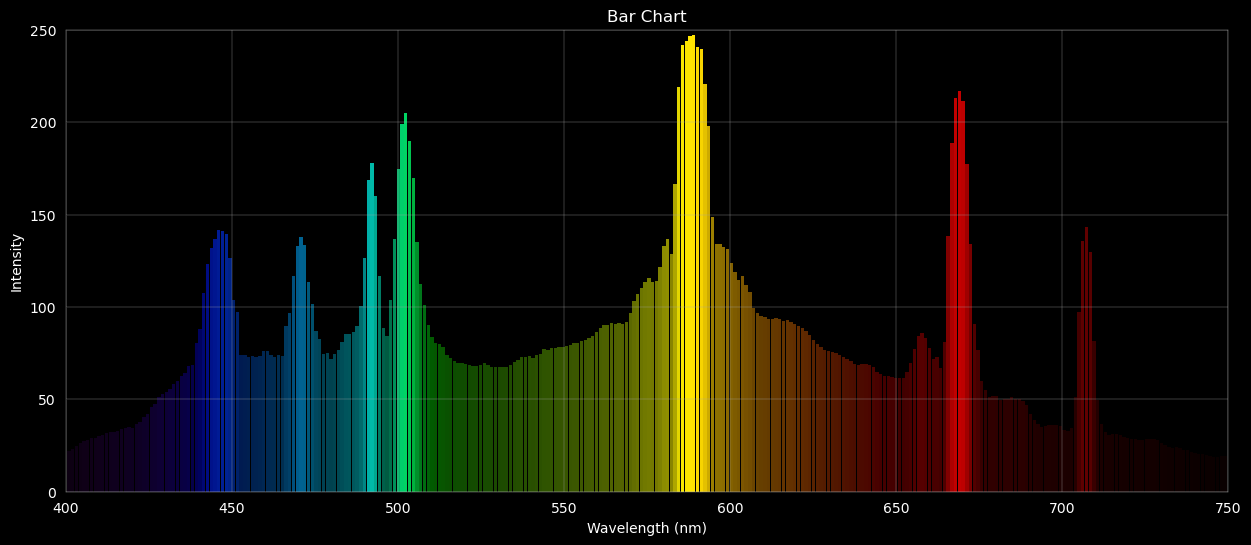

In [87]:
#run_nist_check(df)
#early_exit(df)
plot_other_spec(HE_DF)

text colour: white bg colour: black mode: dark
(res_col_names) Observed Wavelength Air (nm) Rel. Int.
NIST Destriptors Detected. Preparing NIST Rendering.


y lim =  (0.0, 500.0)

Min y synthetic =  0.0 
max y synthetic =  489.9997078859339 
 y max (from int_vals) =  490.0 
norm'd y synth =  0.0


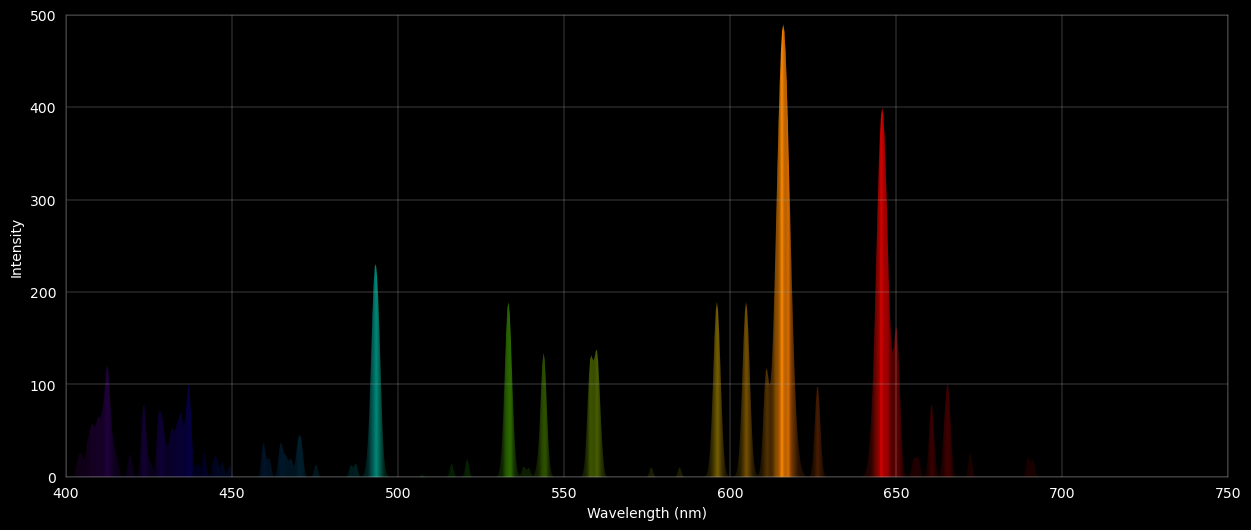

In [71]:
new_utils.axis_labels()
gaussian_iteration(df)

(res_col_names) Observed Wavelength Air (nm) Rel. Int.
(res_col_names) Observed Wavelength Air (nm) Rel. Int.
NIST Destriptors Detected. Preparing NIST Rendering.
mode: dark , fig bg colour: black

overflow: 0.13
o.g. peak label y pos'n: 0.77
needle height goal: 0.539568345323741 
 	 inches: 2.25
current needle height (in): 3.1275
height: 4.17 max label y: 0.9

peak label y pos'n goal: 0.5539568345323741 
new fig height: 4.17
DEBUG: max_label_y = 0.9

 new peak label pos'n: 0.5539568345323741

DEBUG: fig height =  4.17 
 current needle height =  0.539568345323741


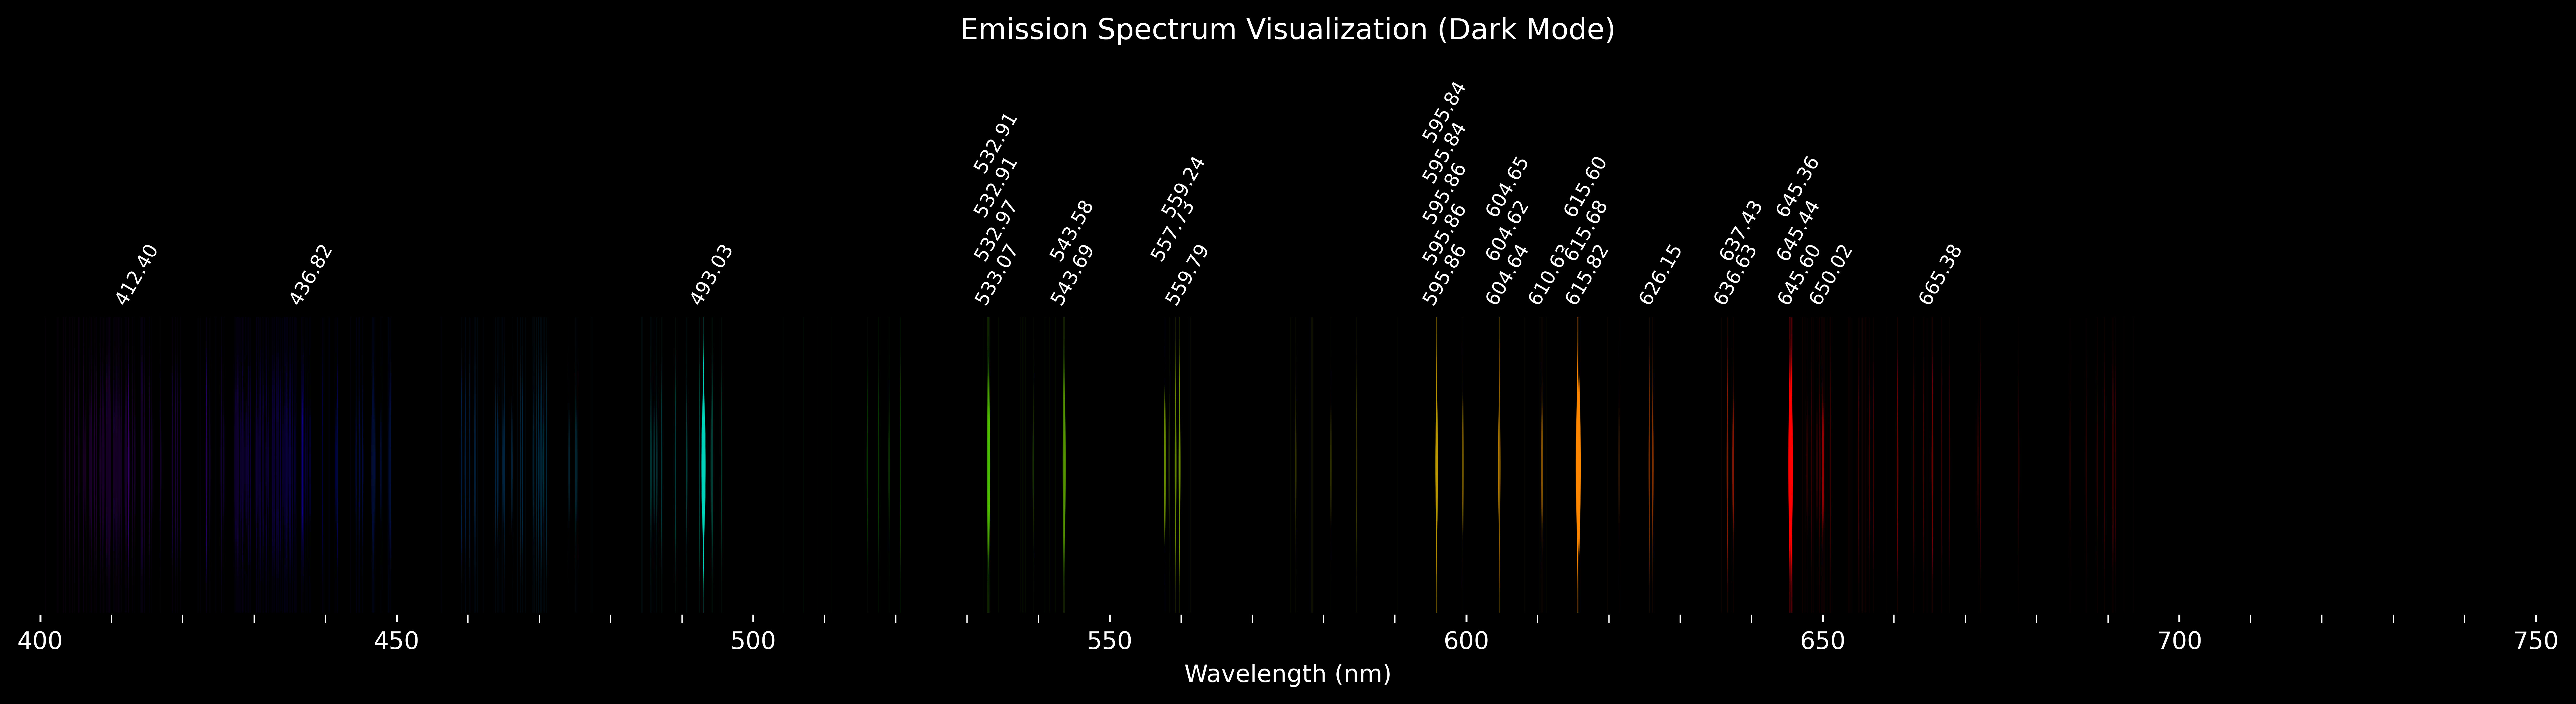

('nist', 'traditional')

In [ ]:
detect_prep(df)

In [ ]:
#plot_other_spec(HE_DF)